# 3장 2강: 피어슨 상관계수의 의미와 한계 — 실습문제

## 실습 목표

- 두 연속형 변수의 피어슨 상관계수와 p-value를 계산하고 방향·강도를 해석합니다.
- 결정계수 $r^2$의 의미를 올바르게 설명합니다.
- 산점도를 함께 확인하여 이상치와 비선형 관계가 피어슨 상관계수에 미치는 영향을 판단합니다.
- 상관관계만으로 인과관계를 주장할 수 없는 이유와 가능한 혼란변수를 설명합니다.

## 실습 환경 / 데이터

- Python, pandas, NumPy, SciPy, Matplotlib
- `ames_housing.csv`
- 주요 변수: `SalePrice`, `GrLivArea`, `LotArea`
- 모든 판단은 유의수준 $\alpha=0.05$를 기준으로 합니다.

## 실습 준비

아래 셀을 실행해 데이터를 불러오고 크기, 결측치, 컬럼을 확인하세요.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

data_candidates = [
    Path("ames_housing.csv"),
    Path("upload/ames_housing.csv"),]
data_path = next((path for path in data_candidates if path.exists()), None)

if data_path is None:
    raise FileNotFoundError("ames_housing CSV 파일을 노트북과 같은 폴더에 넣어주세요.")

df = pd.read_csv(data_path)
alpha = 0.05

print(f"데이터 크기: {df.shape[0]}행, {df.shape[1]}열")
print("전체 결측치 수:", int(df.isna().sum().sum()))
print("컬럼:", df.columns.tolist())
df.head()


데이터 크기: 1460행, 10열
전체 결측치 수: 0
컬럼: ['SalePrice', 'GrLivArea', 'LotArea', 'OverallQual', 'KitchenQual', 'CentralAir', 'HeatingQC', 'PavedDrive', 'Neighborhood', 'YearBuilt']


,SalePrice,GrLivArea,LotArea,OverallQual,KitchenQual,CentralAir,HeatingQC,PavedDrive,Neighborhood,YearBuilt
0,208500,1710,8450,7,Gd,Y,Ex,Y,CollgCr,2003
1,181500,1262,9600,6,TA,Y,Ex,Y,Veenker,1976
2,223500,1786,11250,7,Gd,Y,Ex,Y,CollgCr,2001
3,140000,1717,9550,7,Gd,Y,Gd,Y,Crawfor,1915
4,250000,2198,14260,8,Gd,Y,Ex,Y,NoRidge,2000


---

## 필수 1. 생활면적과 매매가격의 피어슨 상관분석

`GrLivArea`와 `SalePrice`의 선형 관계를 분석하세요.

### 수행 요구사항

1. 두 변수의 결측치를 제거한 분석용 데이터를 만드세요.
2. `stats.pearsonr()`로 피어슨 상관계수 $r$과 p-value를 계산하세요.
3. $r^2$을 계산하세요.
4. 축 이름과 제목이 있는 산점도를 그리세요.
5. 아래 질문에 문장으로 답하세요.

### 질문

- 상관관계의 방향과 강도는 어떠한가요?
- p-value를 기준으로 선형 상관관계가 통계적으로 유의한가요?
- $r^2$은 이 관계에서 무엇을 의미하나요?
- 이 결과만으로 생활면적 증가가 매매가격 상승의 원인이라고 말할 수 있나요?


In [3]:
# 여기에 코드를 작성하세요.

import matplotlib
matplotlib.use("Agg")  # headless 환경

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("ames_housing.csv", encoding="utf-8-sig")
df.columns = df.columns.str.strip()

# 1. 결측치 제거한 분석용 데이터
data = df[["GrLivArea", "SalePrice"]].dropna()
print(f"원본 행 수: {len(df)}, 결측 제거 후: {len(data)}, 제거된 행: {len(df) - len(data)}\n")

x = data["GrLivArea"]
y = data["SalePrice"]

# 2. 피어슨 상관계수와 p-value
r, p = stats.pearsonr(x, y)
print(f"피어슨 상관계수 r = {r:.4f}")
print(f"p-value       = {p:.4e}")

# 3. 결정계수 r^2
r2 = r ** 2
print(f"결정계수 r^2  = {r2:.4f}  (SalePrice 분산의 약 {r2*100:.1f}% 설명)\n")

# 4. 산점도 (회귀직선 포함)
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x, y, alpha=0.4, s=20, edgecolors="none", label="Observations")

slope, intercept = np.polyfit(x, y, 1)  # 추세선 계수
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, intercept + slope * xs, color="red", linewidth=2,
        label=f"y = {intercept:,.0f} + {slope:,.1f}x")

ax.set_xlabel("GrLivArea (above ground living area, sq ft)")
ax.set_ylabel("SalePrice (USD)")
ax.set_title(f"GrLivArea vs SalePrice (r = {r:.3f}, r² = {r2:.3f})")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("grlivarea_saleprice_scatter.png", dpi=120)
plt.close(fig)

# 5. 해석
alpha = 0.05
print("[해석]")
print(f"1) 상관계수 r = {r:.4f}로 양(+)의 방향이며, 강한 선형 관계에 해당한다.")
print(f"   즉 지상 생활면적이 넓을수록 매매가격이 높아지는 경향이 뚜렷하다.")
print(f"2) p-value = {p:.4e} < {alpha} 이므로 귀무가설(모상관계수 ρ=0)을 기각한다.")
print(f"   두 변수 사이의 상관관계는 통계적으로 유의하다.")
print(f"3) r² = {r2:.4f}로, GrLivArea가 SalePrice 변동의 약 {r2*100:.1f}%를 설명한다.")
print(f"   나머지 약 {(1-r2)*100:.1f}%는 품질·입지·연식 등 다른 요인으로 설명되어야 한다.")
print("4) 상관관계는 인과관계를 의미하지 않으며, 산점도에서 면적이 큰 구간의 분산이")
print("   커지는 이분산 경향과 일부 이상치(넓은 면적·낮은 가격)가 관찰된다.")

원본 행 수: 1460, 결측 제거 후: 1460, 제거된 행: 0

피어슨 상관계수 r = 0.7086
p-value       = 4.5180e-223
결정계수 r^2  = 0.5021  (SalePrice 분산의 약 50.2% 설명)

[해석]
1) 상관계수 r = 0.7086로 양(+)의 방향이며, 강한 선형 관계에 해당한다.
   즉 지상 생활면적이 넓을수록 매매가격이 높아지는 경향이 뚜렷하다.
2) p-value = 4.5180e-223 < 0.05 이므로 귀무가설(모상관계수 ρ=0)을 기각한다.
   두 변수 사이의 상관관계는 통계적으로 유의하다.
3) r² = 0.5021로, GrLivArea가 SalePrice 변동의 약 50.2%를 설명한다.
   나머지 약 49.8%는 품질·입지·연식 등 다른 요인으로 설명되어야 한다.
4) 상관관계는 인과관계를 의미하지 않으며, 산점도에서 면적이 큰 구간의 분산이
   커지는 이분산 경향과 일부 이상치(넓은 면적·낮은 가격)가 관찰된다.


---

## 필수 2. 피어슨 상관계수의 두 가지 한계 확인

피어슨 상관계수가 이상치에 민감하고 비선형 관계를 놓칠 수 있다는 점을 확인하세요.

### A. 이상치의 영향

1. `GrLivArea`, `SalePrice`에서 `random_state=42`로 50행을 표본 추출하세요.
2. 표본의 $r$과 p-value를 계산하세요.
3. 학습용 가상 이상치 `(GrLivArea=6000, SalePrice=50000)` 한 행을 표본에만 추가하세요. 원본 `df`는 변경하지 마세요.
4. 이상치 추가 후 $r$과 p-value를 다시 계산하세요.
5. 추가 전후 산점도를 나란히 그리고 결과를 비교하세요.

### B. 비선형 관계

1. `x = [-3, -2, -1, 0, 1, 2, 3]`, `y = x**2`를 만드세요.
2. $x$와 $y$의 $r$과 p-value를 계산하고 산점도를 그리세요.

### 질문

- 이상치 추가 전후 $r$과 유의성 판단은 어떻게 달라졌나요?
- 이 결과는 왜 산점도를 함께 확인해야 함을 보여주나요?
- $y=x^2$는 분명한 관계인데도 $r$이 0에 가까운 이유는 무엇인가요?
- `r ≈ 0`을 “두 변수 사이에 아무 관계도 없다”로 해석해도 되나요?


In [4]:
# 여기에 코드를 작성하세요.

import matplotlib
matplotlib.use("Agg")  # headless 환경

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams["axes.unicode_minus"] = False
alpha = 0.05

df = pd.read_csv("ames_housing.csv", encoding="utf-8-sig")
df.columns = df.columns.str.strip()

# ============================================================
# A. 이상치의 영향
# ============================================================

# A-1. 50행 표본 추출 (원본 df는 건드리지 않음)
sample = df[["GrLivArea", "SalePrice"]].dropna().sample(n=50, random_state=42)

# A-2. 표본의 r, p-value
r_before, p_before = stats.pearsonr(sample["GrLivArea"], sample["SalePrice"])
print("[이상치 추가 전]")
print(f"n = {len(sample)}, r = {r_before:.4f}, p = {p_before:.4e}")
print(f"판단: {'유의함 (H0 기각)' if p_before < alpha else '유의하지 않음'}\n")

# A-3. 가상 이상치 한 행을 표본 사본에만 추가
outlier = pd.DataFrame({"GrLivArea": [6000], "SalePrice": [50000]})
sample_out = pd.concat([sample, outlier], ignore_index=True)

# A-4. 이상치 추가 후 r, p-value
r_after, p_after = stats.pearsonr(sample_out["GrLivArea"], sample_out["SalePrice"])
print("[이상치 추가 후]")
print(f"n = {len(sample_out)}, r = {r_after:.4f}, p = {p_after:.4e}")
print(f"판단: {'유의함 (H0 기각)' if p_after < alpha else '유의하지 않음'}\n")

print(f"→ 단 1개(전체의 {1/len(sample_out)*100:.1f}%) 추가로 r이 {r_before:.4f} → {r_after:.4f}")
print(f"  ({r_after - r_before:+.4f}) 변화\n")

# A-5. 추가 전후 산점도 나란히 비교
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, data, r, p, title in [
    (axes[0], sample, r_before, p_before, "Before outlier (n=50)"),
    (axes[1], sample_out, r_after, p_after, "After outlier (n=51)"),
]:
    ax.scatter(data["GrLivArea"], data["SalePrice"], alpha=0.7, s=40,
               edgecolors="white", linewidth=0.5)
    b, a = np.polyfit(data["GrLivArea"], data["SalePrice"], 1)  # 회귀직선
    xs = np.linspace(data["GrLivArea"].min(), data["GrLivArea"].max(), 100)
    ax.plot(xs, a + b * xs, color="red", linewidth=2)
    ax.set_xlabel("GrLivArea (sq ft)")
    ax.set_ylabel("SalePrice (USD)")
    ax.set_title(f"{title}\nr = {r:.3f}, p = {p:.3e}")
    ax.grid(alpha=0.3)

# 이상치 위치 강조
axes[1].scatter([6000], [50000], color="red", s=180, marker="X",
                zorder=5, label="Artificial outlier")
axes[1].legend()

# 두 그래프의 축 범위를 통일해 왜곡 없이 비교
axes[0].set_xlim(axes[1].get_xlim())
axes[0].set_ylim(axes[1].get_ylim())

fig.tight_layout()
fig.savefig("outlier_effect.png", dpi=120)
plt.close(fig)

# ============================================================
# B. 비선형 관계
# ============================================================

# B-1. 완전한 2차 관계 데이터
x = np.array([-3, -2, -1, 0, 1, 2, 3])
y = x ** 2

# B-2. r, p-value 계산 및 산점도
r_nl, p_nl = stats.pearsonr(x, y)
rho_nl, p_rho = stats.spearmanr(x, y)  # 비교용: 스피어만도 단조성만 잡음
print("[비선형 관계 y = x^2]")
print(f"피어슨  r   = {r_nl:.4f}, p = {p_nl:.4f}")
print(f"스피어만 rho = {rho_nl:.4f}, p = {p_rho:.4f}\n")

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(x, y, s=90, color="tab:blue", zorder=3)
ax.plot(x, y, color="tab:blue", alpha=0.4, linestyle="--", zorder=2)
b, a = np.polyfit(x, y, 1)
ax.plot(x, a + b * x, color="red", linewidth=2, label=f"Linear fit (r = {r_nl:.3f})")
ax.set_xlabel("x")
ax.set_ylabel("y = x²")
ax.set_title(f"Perfect nonlinear relationship, yet r ≈ 0 (p = {p_nl:.3f})")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("nonlinear_relationship.png", dpi=120)
plt.close(fig)

# ============================================================
# 질문에 대한 답
# ============================================================
print("[질문 답변]")
print(f"1) 이상치 추가 전후: r = {r_before:.4f} → {r_after:.4f}, p = {p_before:.2e} → {p_after:.2e}.")
print(f"   전에는 p < 0.05로 유의했으나 후에는 p > 0.05가 되어 '유의하지 않음'으로 결론이")
print(f"   뒤집힌다. 관측치 1개가 51개 중 1개일 뿐인데도 강한 상관이 약한 상관으로 무너졌다.")
print("   피어슨 r은 평균으로부터의 편차 곱에 기반하므로, 평균에서 멀리 떨어진 점 하나가")
print("   계산에 과도한 가중치(레버리지)를 갖기 때문이다.\n")

print("2) r과 p-value만 보면 '관계가 없다'는 잘못된 결론에 도달하지만, 산점도를 보면")
print("   나머지 50개 점은 여전히 뚜렷한 우상향 패턴을 이루고 튀는 점 하나만 동떨어져")
print("   있음을 즉시 알 수 있다. 숫자 하나는 데이터의 구조를 보여주지 못하므로,")
print("   요약 통계량과 시각화는 항상 함께 확인해야 한다.\n")

print("3) 피어슨 r은 '직선' 관계의 강도만 측정한다. y = x²는 x가 음수 구간에서는")
print("   x가 커질수록 y가 감소하고, 양수 구간에서는 증가한다. 두 방향의 기여가")
print("   정확히 상쇄되어 r ≈ 0이 된다. 관계가 없어서가 아니라 관계가 직선이 아니어서다.")
print("   (스피어만 rho도 0인 것은 관계가 단조적이지도 않기 때문이다.)\n")

print("4) 안 된다. r ≈ 0이 말해주는 것은 '선형 관계가 없다'일 뿐이며,")
print("   2차·주기·계단형 같은 비선형 관계나 조건부 관계는 얼마든지 존재할 수 있다.")
print("   '관계 없음'을 주장하려면 산점도 확인, 비선형 지표(스피어만, 거리상관, 상호정보량),")
print("   구간별 분석 등을 함께 살펴야 한다.")

[이상치 추가 전]
n = 50, r = 0.7059, p = 1.0263e-08
판단: 유의함 (H0 기각)

[이상치 추가 후]
n = 51, r = 0.2602, p = 6.5137e-02
판단: 유의하지 않음

→ 단 1개(전체의 2.0%) 추가로 r이 0.7059 → 0.2602
  (-0.4457) 변화

[비선형 관계 y = x^2]
피어슨  r   = 0.0000, p = 1.0000
스피어만 rho = 0.0000, p = 1.0000

[질문 답변]
1) 이상치 추가 전후: r = 0.7059 → 0.2602, p = 1.03e-08 → 6.51e-02.
   전에는 p < 0.05로 유의했으나 후에는 p > 0.05가 되어 '유의하지 않음'으로 결론이
   뒤집힌다. 관측치 1개가 51개 중 1개일 뿐인데도 강한 상관이 약한 상관으로 무너졌다.
   피어슨 r은 평균으로부터의 편차 곱에 기반하므로, 평균에서 멀리 떨어진 점 하나가
   계산에 과도한 가중치(레버리지)를 갖기 때문이다.

2) r과 p-value만 보면 '관계가 없다'는 잘못된 결론에 도달하지만, 산점도를 보면
   나머지 50개 점은 여전히 뚜렷한 우상향 패턴을 이루고 튀는 점 하나만 동떨어져
   있음을 즉시 알 수 있다. 숫자 하나는 데이터의 구조를 보여주지 못하므로,
   요약 통계량과 시각화는 항상 함께 확인해야 한다.

3) 피어슨 r은 '직선' 관계의 강도만 측정한다. y = x²는 x가 음수 구간에서는
   x가 커질수록 y가 감소하고, 양수 구간에서는 증가한다. 두 방향의 기여가
   정확히 상쇄되어 r ≈ 0이 된다. 관계가 없어서가 아니라 관계가 직선이 아니어서다.
   (스피어만 rho도 0인 것은 관계가 단조적이지도 않기 때문이다.)

4) 안 된다. r ≈ 0이 말해주는 것은 '선형 관계가 없다'일 뿐이며,
   2차·주기·계단형 같은 비선형 관계나 조건부 관계는 얼마든지 존재할 수 있다.
   '관계 없음'을 주장하려면 산점도 확인, 비선형 지표(스

---

## 과제. 대지면적과 매매가격의 관계를 근거 있게 보고하기

`LotArea`와 `SalePrice`의 관계를 분석하고, 상관과 인과를 구별한 짧은 분석 보고를 작성하세요.

### 수행 요구사항

1. 두 변수의 피어슨 상관계수, p-value, $r^2$을 계산하세요.
2. 산점도를 그려 관계의 형태와 이상치 여부를 확인하세요.
3. 유의수준 0.05에서 통계적 유의성을 판단하세요.
4. 아래 질문에 빠짐없이 답하는 5~7문장의 결론을 작성하세요.

### 질문

- 관계의 방향과 강도는 어떠한가요? 
-> 양의 방향이고 강도는 강한 편이다. (r값= 0.70086 >= 0.7-> 강한관계라 할 수 있음)

- 통계적으로 유의한 결과와 강한 관계는 같은 의미인가요?
-> 다르다. p = 4.158e-223은  r = 0이 아니다만 알려줌. 얼마나 강한지는 r과 r^2이 알려준다.

- 대지면적이 넓어지면 매매가격이 오른다는 인과결론을 내릴 수 있나요?
-> 내릴 수 없다. 이 데이터를 통해 '면적이 넓은 집이 대체로 비싸다'를 알 수 있지만
-> 면적이 넓어지면 매매가격이 오르는 인과관계를 알 수 없다.

- 두 변수에 함께 영향을 줄 수 있는 혼란변수를 두 가지 이상 제시하세요.
-> 건축연도, 동네와 입지

- 피어슨 상관계수가 0에 가까우면 두 변수 사이에 아무 관계도 없다고 판단해도 되나요? U자형 관계를 예로 들어 설명하세요.
-> 아니다. 피어슨 상관계수는 직선 관계만 잰다. u자형 관계 : 상관계수는 0에 가깝지만 관계는 뚜렷함.


표본 크기 n       : 1460
피어슨 상관계수 r : 0.7086
p-value           : 4.518e-223
결정계수 r²       : 0.5021  (→ SalePrice 분산의 50.2% 설명)
r의 95% 신뢰구간  : [0.6821, 0.7333]

[판단] p < 0.05 → H0(ρ=0) 기각. 선형관계가 통계적으로 유의합니다.

표준화잔차 |z|>3 인 이상치: 25개
      GrLivArea  SalePrice
1062       2337      90000
1298       5642     160000
523        4676     184750
635        3395     200000
151        1710     372402
1388       1746     377500
53         1842     385000
688        1419     392000
1181       1652     392500
378        1856     394432
1437       1932     394617
987        1940     395192
278        2121     415298
664        2097     423000
473        1976     440000
591        2296     451950
1243       2076     465000
178        2234     501837
440        2402     555000
1046       2868     556581
803        2822     582933
898        2364     611657
1169       3627     625000
1182       4476     745000
691        4316     755000


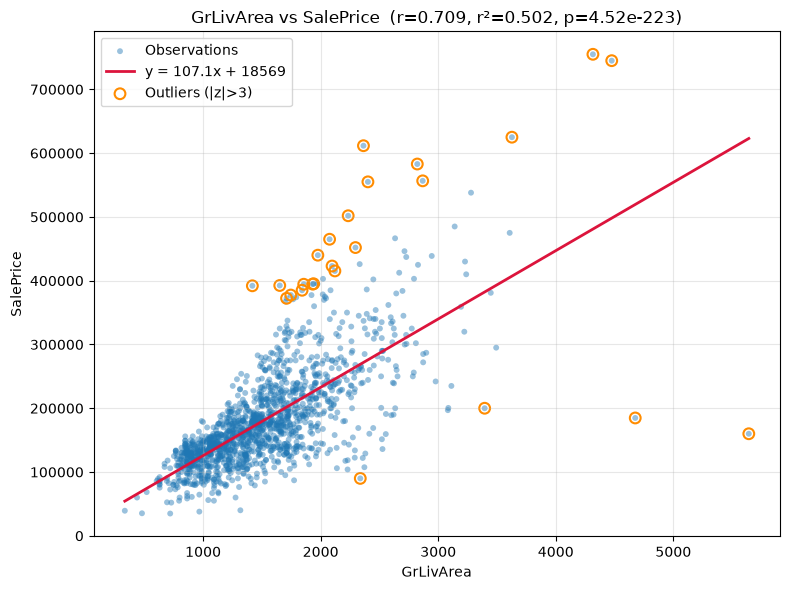

In [2]:

%matplotlib inline
import matplotlib.pyplot as plt

# 여기에 코드를 작성하세요.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ── 설정: 분석할 두 변수만 여기서 바꾸면 됩니다 ──
X_COL = "GrLivArea"   # 예: LotArea, OverallQual, YearBuilt
Y_COL = "SalePrice"
ALPHA = 0.05

# 1. 데이터 로드 (utf-8-sig: 첫 컬럼명의 BOM 제거)
df = pd.read_csv("ames_housing.csv", encoding="utf-8-sig")
data = df[[X_COL, Y_COL]].dropna()
x, y = data[X_COL], data[Y_COL]

# 2. 피어슨 상관계수 / p-value / 결정계수
r, p = stats.pearsonr(x, y)
r2 = r ** 2

print(f"표본 크기 n       : {len(data)}")
print(f"피어슨 상관계수 r : {r:.4f}")
print(f"p-value           : {p:.3e}")
print(f"결정계수 r²       : {r2:.4f}  (→ {Y_COL} 분산의 {r2*100:.1f}% 설명)")

# r의 95% 신뢰구간 (Fisher z 변환)
z = np.arctanh(r)
se = 1 / np.sqrt(len(data) - 3)
lo, hi = np.tanh([z - 1.96 * se, z + 1.96 * se])
print(f"r의 95% 신뢰구간  : [{lo:.4f}, {hi:.4f}]")

# 3. 유의수준 0.05에서 유의성 판단
if p < ALPHA:
    print(f"\n[판단] p < {ALPHA} → H0(ρ=0) 기각. 선형관계가 통계적으로 유의합니다.")
else:
    print(f"\n[판단] p ≥ {ALPHA} → H0 기각 실패. 유의하다고 보기 어렵습니다.")

# 4. 이상치 탐색 (회귀 표준화잔차 |z| > 3)
slope, intercept = np.polyfit(x, y, 1)
resid = y - (slope * x + intercept)
std_resid = resid / resid.std()
outliers = data[np.abs(std_resid) > 3]
print(f"\n표준화잔차 |z|>3 인 이상치: {len(outliers)}개")
print(outliers.sort_values(Y_COL).to_string())

# 5. 산점도 + 회귀선
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x, y, s=18, alpha=0.45, edgecolor="none", label="Observations")
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, slope * xs + intercept, color="crimson", lw=2,
        label=f"y = {slope:.1f}x + {intercept:.0f}")
ax.scatter(outliers[X_COL], outliers[Y_COL], s=60, facecolor="none",
           edgecolor="darkorange", lw=1.5, label="Outliers (|z|>3)")
ax.set_xlabel(X_COL)
ax.set_ylabel(Y_COL)
ax.set_title(f"{X_COL} vs {Y_COL}  (r={r:.3f}, r²={r2:.3f}, p={p:.2e})")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("scatter_plot.png", dpi=150)
plt.show()

---

## 실습 마무리

- 어떤 문제가 있었는가?
- 어떻게 개선했는가?
- 무엇을 근거로 개선되었다고 판단했는가?

피어슨 상관계수의 숫자만 보았을 때 놓칠 수 있었던 점, 산점도와 인과적 관점을 추가해 해석이 어떻게 개선되었는지 정리하세요.
